In [1]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

2026-03-28 15:54:29.841465: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-28 15:54:29.904521: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-28 15:54:32.453409: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
from data_degrading import degrade_spectrum
import abcsn_training
import abcsn_config

sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_project")
from process_data import *
from plot_data import *


sys.path.insert(0, "/lustre/lrspec/users/4301/snidpy/sourcepy")
from apodize import *
from logwave import Logwave as lw
from logwave import log_rebin

In [3]:
# used:
# abcsn_config.SN_Stypes_int_to_str replaced with ABC_subtype_id_to_str
# to make the dictionary corresponding to the labels used above
# may just want to change the above to use the same strings as int_to_str function
ABC_subtype_id_to_str = {
    0: "Ia-norm",
    1: "Ia-91T",
    2: "Ia-91bg",
    3: "Iax",
    4: "Ib-norm",
    5: "Ibn",
    6: "IIb",
    7: "Ic-norm",
    8: "Ic-broad",
    9: "IIP",
}

ABC_ID_dict ={"Ia": 0,
          "Iap": 0,
          "Ic": 7,
          "Ib": 4,
          "II": 9, # IIP = type 2 plateau = normal
          "IIb": 6,
          "IIn": 9,
          "SL": None,
          "TDE": None,
          "CRT": None
          }

Mill_ID_dict ={"Ia": 0,
          "Iap": 0,
          "Ic": 1,
          "Ib": 1,
          "II": 2, # IIP = type 2 plateau = normal
          "IIb": 1,
          "IIn": 2,
          "SL": 3,
          "TDE": 4,
          "CRT": 4
          }

# five types recorded in Milligan et al.
Mill_types_to_int = {0: "Ia",
                     1: "Ib & Ic",
                     2: "II",
                     3: "SLSN",
                     4: "Non-SN",
                     5: "other"
                     }

# convert ABC types to Mill categories
ABC_to_Mill ={0:0,   # Ia-norm -> Ia
              1:0,   # Ia-91T -> Ia
              2:0,   # Ia-91bg -> Ia
              3:0,   # Iax -> Ia
              4:1,   # Ib-norm -> Ib & Ic
              5:1,   # Ibn -> Ib & Ic
              6:1,   # IIb -> Ib & Ic
              7:1,  # Ic-norm -> Ib & Ic
              8:1,  # Ic-broad -> Ib & Ic
              9:2,  # IIP -> II
            }

In [4]:
filenames = glob.glob("/lustre/lrspec/users/4301/Milligan_ABC-SN/data/csvs/*")
columns = ['filename', 'host', 'sn_type', 'redshift', 'SN_mag', 'host_mag',
           'ABC_ID', 'Mill_ID', 'Pred_ABC_ID', 'Pred_Mill_ID']
df = pd.DataFrame(columns = columns)
for file in filenames: 
    temp_df = pd.read_csv(file,na_filter=False )
    df = pd.concat([df, temp_df], ignore_index=True)
    

/tmp/ipykernel_19423/3106409603.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, temp_df], ignore_index=True)


In [5]:
df.Pred_Mill_ID = df.Pred_Mill_ID.astype(float)
df.Pred_ABC_ID = df.Pred_ABC_ID.astype(float)


# confusion matricies 

/lustre/lrspec/users/4301/Milligan_ABC-SN/plot_data.py:12: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / np.nansum(cm, axis=1)[:, np.newaxis]


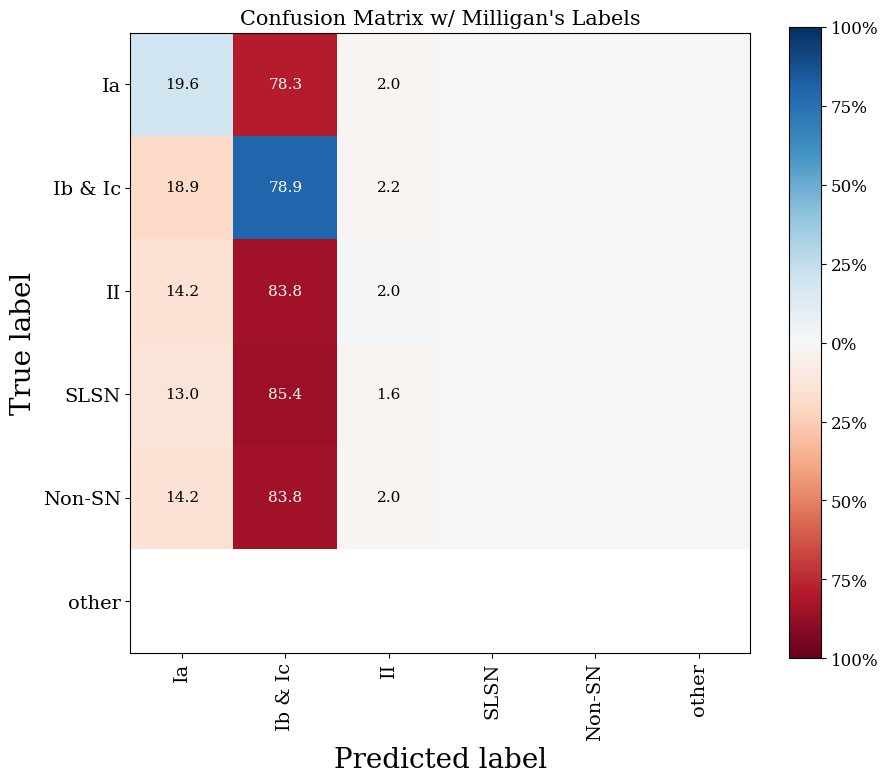

In [6]:
cm_mill = confusion_matrix(df.Mill_ID, df.Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill, list(Mill_types_to_int.values()), title = "Confusion Matrix w/ Milligan's Labels")

In [7]:
index = df.ABC_ID.values!="" # index of SN ONLY (excluding SLSN)
SN_df = df[index].copy()
SN_df = SN_df.reset_index()
SN_df.ABC_ID = SN_df.ABC_ID.astype(float)


/lustre/lrspec/users/4301/Milligan_ABC-SN/plot_data.py:12: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / np.nansum(cm, axis=1)[:, np.newaxis]


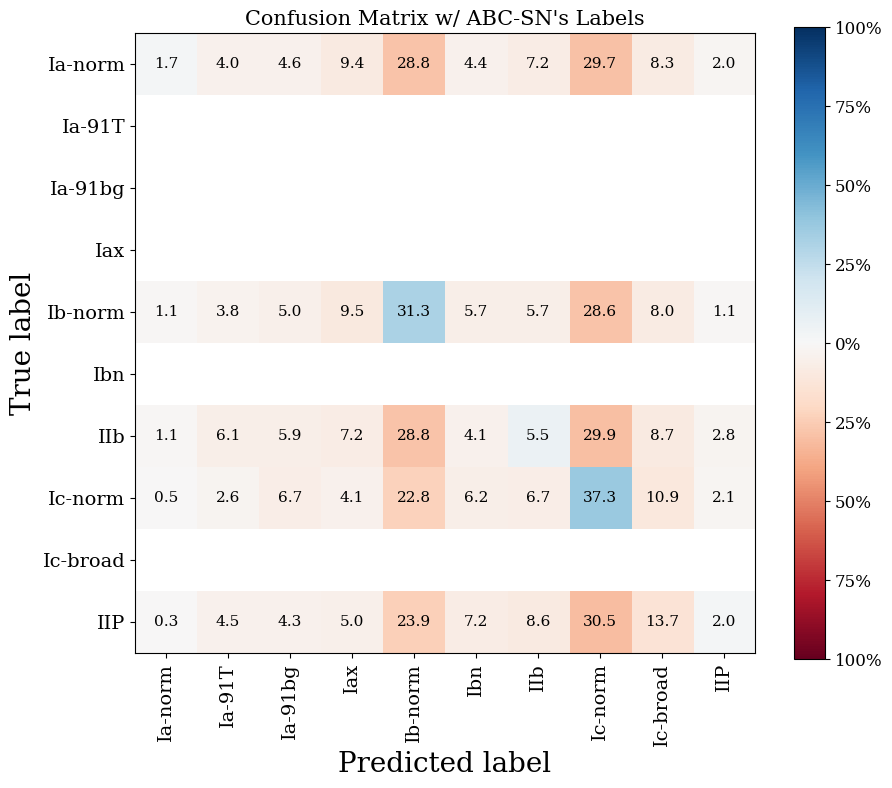

In [8]:
cm_abc = confusion_matrix(SN_df.ABC_ID, SN_df.Pred_ABC_ID) #, 
                           #labels=list(ABC_subtype_id_to_str.values()))
plot = plot_cm(cm_abc, list(ABC_subtype_id_to_str.values()), title = "Confusion Matrix w/ ABC-SN's Labels")

# confusion matricies z < 0.05

/lustre/lrspec/users/4301/Milligan_ABC-SN/plot_data.py:12: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / np.nansum(cm, axis=1)[:, np.newaxis]


data length:  458


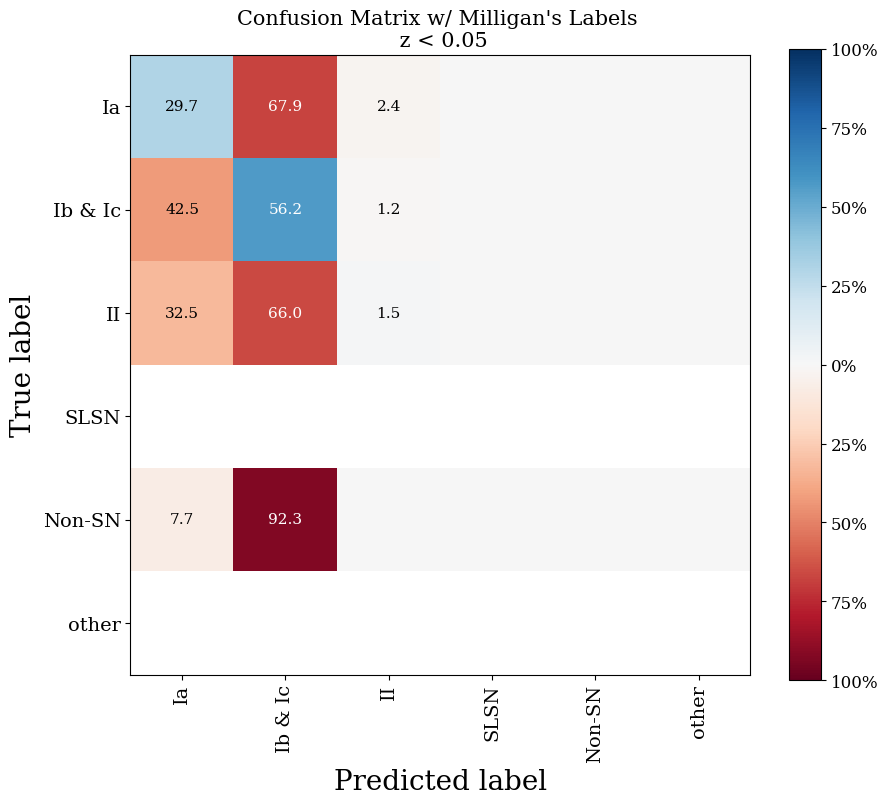

In [9]:
small_z_index = df.redshift < 0.05
cm_mill = confusion_matrix(df[small_z_index].Mill_ID, df[small_z_index].Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill, list(Mill_types_to_int.values()), 
        title = "Confusion Matrix w/ Milligan's Labels \n z < 0.05")
print("data length: ", sum(small_z_index))

/lustre/lrspec/users/4301/Milligan_ABC-SN/plot_data.py:12: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / np.nansum(cm, axis=1)[:, np.newaxis]


data length:  445


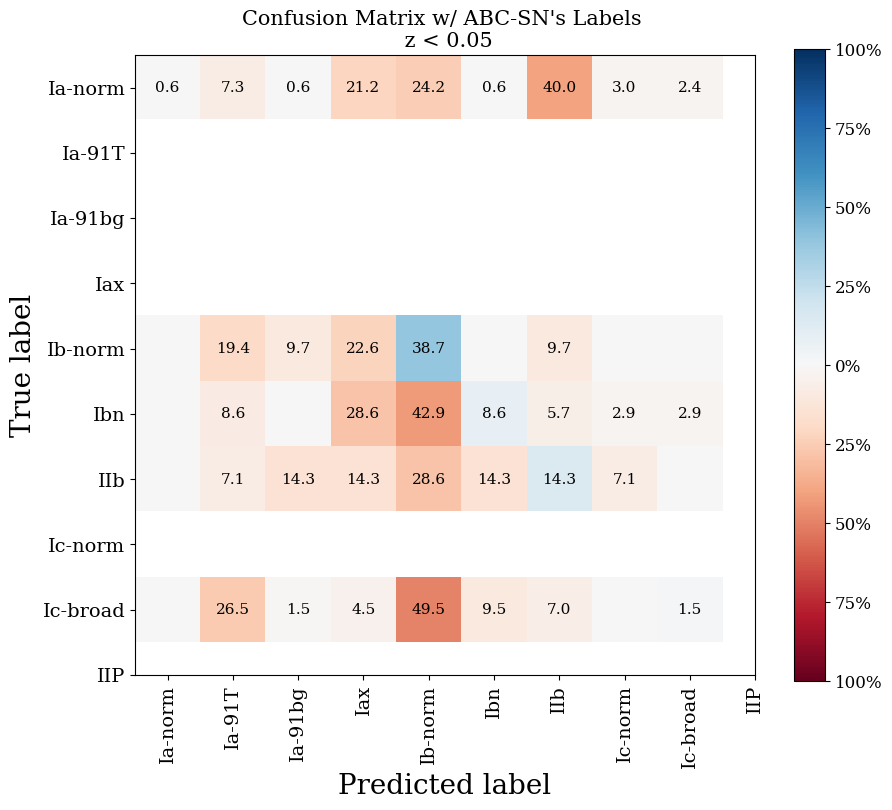

In [10]:
small_z_index = SN_df.redshift < 0.05
cm_abc = confusion_matrix(SN_df[small_z_index].ABC_ID, SN_df[small_z_index].Pred_ABC_ID)
plot = plot_cm(cm_abc, list(ABC_subtype_id_to_str.values()), 
               title = "Confusion Matrix w/ ABC-SN's Labels \n z < 0.05")
print("data length: ", sum(small_z_index))

## low galaxy light + low redshift

In [11]:
brighter_SN_index = df.host_mag > df.SN_mag - 1
print(sum(small_z_index & brighter_SN_index))
bright_close_index = small_z_index & brighter_SN_index

362


/lustre/lrspec/users/4301/Milligan_ABC-SN/plot_data.py:12: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / np.nansum(cm, axis=1)[:, np.newaxis]


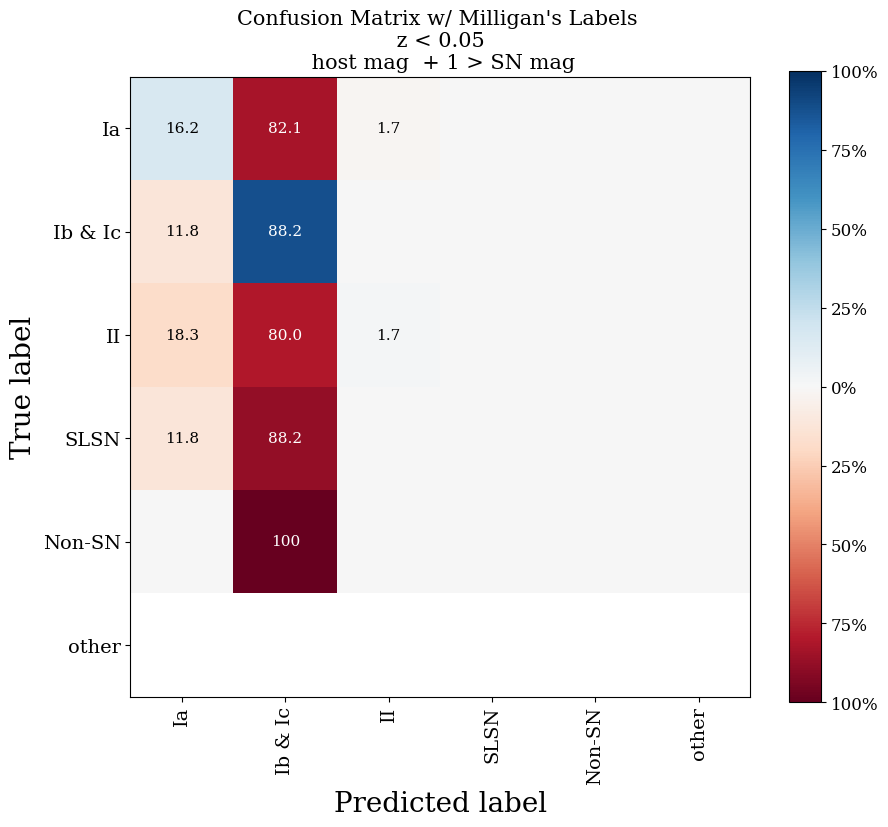

In [12]:
cm_mill = confusion_matrix(df[bright_close_index].Mill_ID, df[bright_close_index].Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill, list(Mill_types_to_int.values()), 
        title = "Confusion Matrix w/ Milligan's Labels \n z < 0.05 \n host mag  + 1 > SN mag")


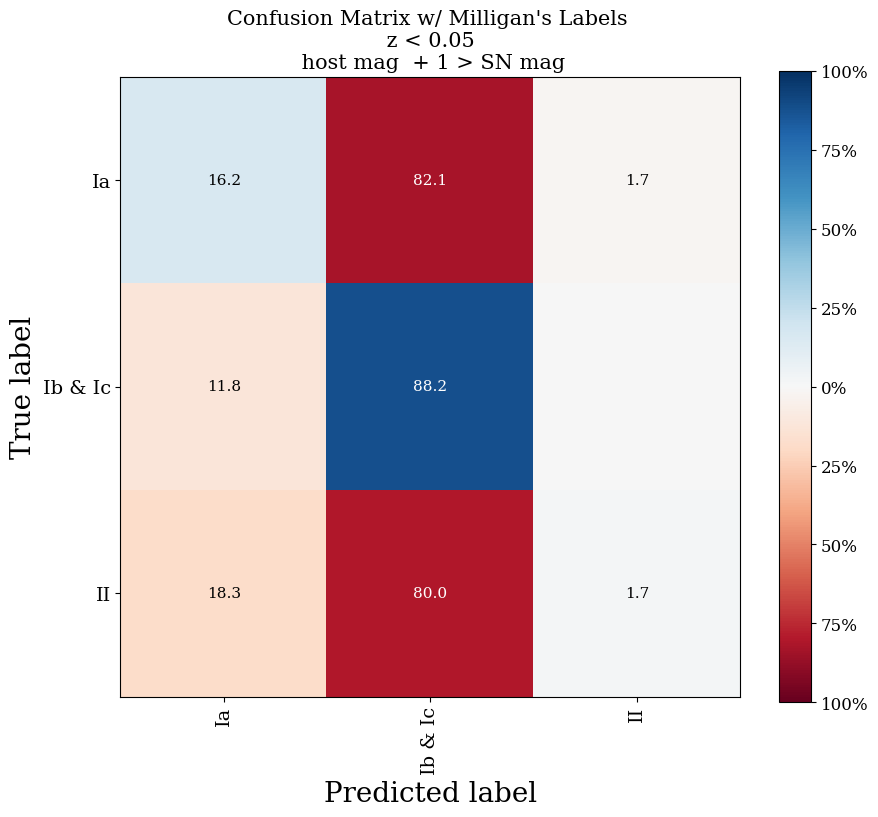

In [13]:
cm_mill[:3, :3]
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3], 
        title = "Confusion Matrix w/ Milligan's Labels \n z < 0.05 \n host mag  + 1 > SN mag")

/tmp/ipykernel_19423/1700862255.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cm_abc = confusion_matrix(SN_df[bright_close_index].ABC_ID, SN_df[bright_close_index].Pred_ABC_ID)
/tmp/ipykernel_19423/1700862255.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cm_abc = confusion_matrix(SN_df[bright_close_index].ABC_ID, SN_df[bright_close_index].Pred_ABC_ID)
/lustre/lrspec/users/4301/Milligan_ABC-SN/plot_data.py:12: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / np.nansum(cm, axis=1)[:, np.newaxis]


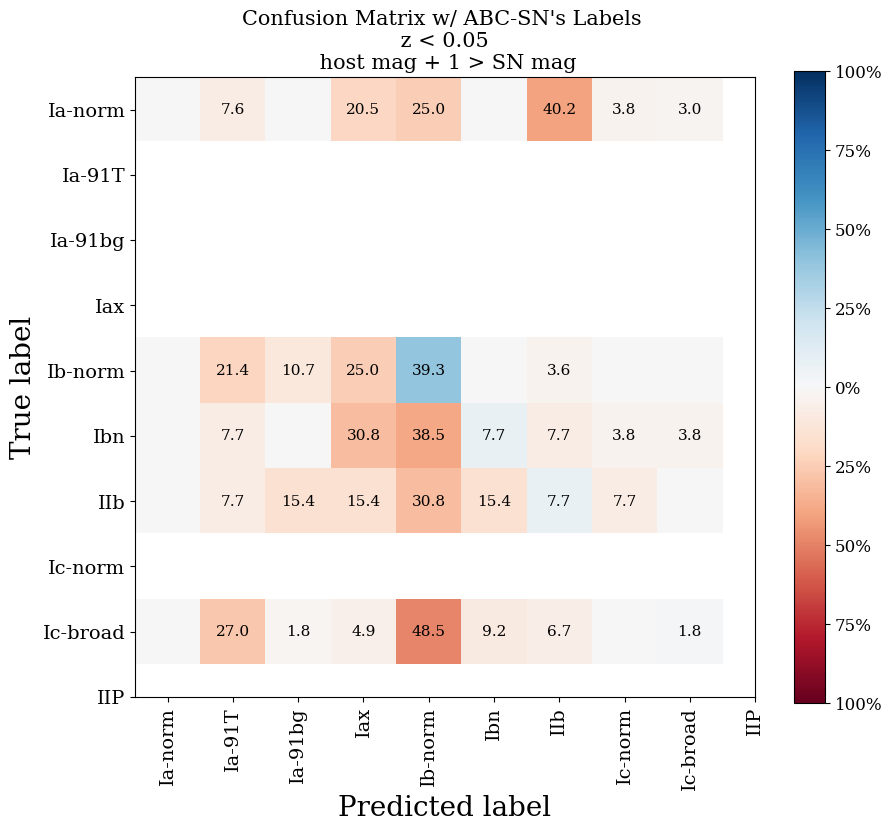

In [14]:
cm_abc = confusion_matrix(SN_df[bright_close_index].ABC_ID, SN_df[bright_close_index].Pred_ABC_ID)
plot = plot_cm(cm_abc, list(ABC_subtype_id_to_str.values()), 
               title = "Confusion Matrix w/ ABC-SN's Labels \n z < 0.05 \n host mag + 1 > SN mag")